# EvidenceLab — 01 · Adaptación de dominio (MLM) — Google Colab T4

**Modelo:** `distilbert-base-multilingual-cased`

Este notebook cubre:

- MLM continuado con `mlm_probability=0.15`
- perplexity antes y después
- primera corrida con 49 unidades documentales
- segunda corrida con **+300 unidades**
- comparación de embeddings de términos del dominio
- curva de entrenamiento
- tracking con MLflow
- exportación de artefactos a Google Drive

> Una **unidad documental** es una página de una resolución judicial. No se afirma que sean 349 PDFs independientes.

## Antes de ejecutar

1. En Colab activa **T4 GPU**.
2. Comprime `data/EvidenceLab_Criminal_ES_v1_0/` como `EvidenceLab_Criminal_ES_v1_0.zip`.
3. Idealmente súbelo a `Mi unidad/EvidenceLab/EvidenceLab_Criminal_ES_v1_0.zip`.

Si no está en Drive, el notebook te pedirá subirlo manualmente.

In [3]:
!pip -q install -U "transformers<5" datasets accelerate mlflow scikit-learn matplotlib pandas

In [1]:
import torch, platform

assert torch.cuda.is_available(), (
    "Activa una GPU en Colab: Entorno de ejecución > Cambiar tipo de entorno de ejecución > T4 GPU."
)

GPU_NAME = torch.cuda.get_device_name(0)
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3

print("GPU:", GPU_NAME)
print(f"VRAM: {VRAM_GB:.2f} GB")
print("CUDA:", torch.version.cuda)
print("PyTorch:", torch.__version__)

GPU: Tesla T4
VRAM: 14.56 GB
CUDA: 12.8
PyTorch: 2.11.0+cu128


In [3]:
from google.colab import drive, files
from pathlib import Path
import zipfile

drive.mount("/content/drive")

DRIVE_ROOT = Path("/content/drive/MyDrive/EvidenceLab")
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

ZIP_IN_DRIVE = DRIVE_ROOT / "EvidenceLab_Criminal_ES_v1_0.zip"
DATA_DIR = Path("/content/EvidenceLab_Criminal_ES_v1_0")

if not DATA_DIR.exists():
    if ZIP_IN_DRIVE.exists():
        zip_path = ZIP_IN_DRIVE
        print("Usando ZIP desde Drive:", zip_path)
    else:
        print("Selecciona EvidenceLab_Criminal_ES_v1_0.zip")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No se subió ningún ZIP.")
        zip_path = Path("/content") / next(iter(uploaded))

    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall("/content")

    if not DATA_DIR.exists():
        matches = list(Path("/content").rglob("EvidenceLab_Criminal_ES_v1_0"))
        if not matches:
            raise FileNotFoundError("No encontré EvidenceLab_Criminal_ES_v1_0 dentro del ZIP.")
        DATA_DIR = matches[0]

print("DATA_DIR:", DATA_DIR)

Mounted at /content/drive
Usando ZIP desde Drive: /content/drive/MyDrive/EvidenceLab/EvidenceLab_Criminal_ES_v1_0.zip
DATA_DIR: /content/EvidenceLab_Criminal_ES_v1_0


In [5]:
import gc, json, math, random, time
from pathlib import Path
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import mlflow

from datasets import Dataset
from sklearn.metrics.pairwise import cosine_similarity
from transformers import (
    AutoTokenizer,
    AutoModelForMaskedLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
    set_seed,
)

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

MODEL_NAME = "distilbert-base-multilingual-cased"
BLOCK_SIZE = 128
MLM_PROBABILITY = 0.15
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 3
TRAIN_BATCH_SIZE = 16
EVAL_BATCH_SIZE = 16

DRIVE_ARTIFACTS = DRIVE_ROOT / "artifacts" / "01_mlm"
DRIVE_ARTIFACTS.mkdir(parents=True, exist_ok=True)

MLRUNS_DIR = DRIVE_ROOT / "mlruns"
MLRUNS_DIR.mkdir(parents=True, exist_ok=True)

# Fix: Allow MLflow to use the filesystem backend
os.environ["MLFLOW_ALLOW_FILE_STORE"] = "true"

mlflow.set_tracking_uri(MLRUNS_DIR.resolve().as_uri())
mlflow.set_experiment("EvidenceLab_MLM")

MLM_DIR = DATA_DIR / "training" / "mlm"
BASE_FILE = MLM_DIR / "corpus_base_49.jsonl"
EXTENDED_FILE = MLM_DIR / "corpus_extended_349.jsonl"
VALIDATION_FILE = MLM_DIR / "validation_44.jsonl"
TEST_FILE = MLM_DIR / "test_65.jsonl"

for p in [BASE_FILE, EXTENDED_FILE, VALIDATION_FILE, TEST_FILE]:
    assert p.exists(), f"Falta: {p}"

2026/08/14 22:30:48 INFO mlflow.tracking.fluent: Experiment with name 'EvidenceLab_MLM' does not exist. Creating a new experiment.


In [6]:
def load_jsonl(path):
    with path.open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

base_records = load_jsonl(BASE_FILE)
extended_records = load_jsonl(EXTENDED_FILE)
validation_records = load_jsonl(VALIDATION_FILE)
test_records = load_jsonl(TEST_FILE)

print("Base:", len(base_records))
print("Extendido:", len(extended_records))
print("Validation:", len(validation_records))
print("Test reservado:", len(test_records))

assert len(base_records) == 49
assert len(extended_records) == 349
assert len(validation_records) == 44
assert len(test_records) == 65

Base: 49
Extendido: 349
Validation: 44
Test reservado: 65


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def records_to_blocks(records, block_size=128):
    ds = Dataset.from_list([{"text": r["text"]} for r in records if r["text"].strip()])

    tokenized = ds.map(
        lambda batch: tokenizer(
            batch["text"],
            add_special_tokens=True,
            return_special_tokens_mask=True,
        ),
        batched=True,
        remove_columns=["text"],
    )

    def group_texts(examples):
        concat = {k: sum(examples[k], []) for k in examples}
        total = (len(concat["input_ids"]) // block_size) * block_size
        return {
            k: [v[i:i+block_size] for i in range(0, total, block_size)]
            for k, v in concat.items()
        }

    return tokenized.map(group_texts, batched=True)

base_ds = records_to_blocks(base_records, BLOCK_SIZE)
extended_ds = records_to_blocks(extended_records, BLOCK_SIZE)
validation_ds = records_to_blocks(validation_records, BLOCK_SIZE)

collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=MLM_PROBABILITY,
)

print("Bloques base:", len(base_ds))
print("Bloques extended:", len(extended_ds))
print("Bloques validation:", len(validation_ds))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Map:   0%|          | 0/349 [00:00<?, ? examples/s]

Map:   0%|          | 0/349 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Bloques base: 225
Bloques extended: 1511
Bloques validation: 232


In [8]:
TRACK_TERMS = [
    "acusado", "testimonio", "indicio", "coautoría", "dictamen",
    "homicidio", "sentencia", "peritaje", "absolución", "culpabilidad",
]

def extract_embeddings(model):
    matrix = model.get_input_embeddings().weight.detach().cpu()
    out = {}
    for term in TRACK_TERMS:
        ids = tokenizer(term, add_special_tokens=False)["input_ids"]
        out[term] = matrix[ids].mean(dim=0).numpy()
    return out

def shift_table(before, after, label):
    rows = []
    for term in TRACK_TERMS:
        b = before[term].reshape(1, -1)
        a = after[term].reshape(1, -1)
        sim = cosine_similarity(b, a)[0, 0]
        rows.append({
            "term": term,
            f"cosine_similarity_{label}": float(sim),
            f"cosine_distance_{label}": float(1 - sim),
            f"euclidean_distance_{label}": float(np.linalg.norm(after[term] - before[term])),
        })
    return pd.DataFrame(rows)

def make_args(output_dir, run_name):
    return TrainingArguments(
        output_dir=str(output_dir),
        overwrite_output_dir=True,
        num_train_epochs=NUM_EPOCHS,
        per_device_train_batch_size=TRAIN_BATCH_SIZE,
        per_device_eval_batch_size=EVAL_BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="no",
        fp16=True,
        report_to=[],
        seed=SEED,
        data_seed=SEED,
        run_name=run_name,
    )

def evaluate_model(model, label):
    trainer = Trainer(
        model=model,
        args=make_args("/content/eval_tmp", f"eval-{label}"),
        eval_dataset=validation_ds,
        data_collator=collator,
        processing_class=tokenizer,
    )
    metrics = trainer.evaluate()
    loss = float(metrics["eval_loss"])
    ppl = float(math.exp(loss))
    print(label, "loss=", loss, "perplexity=", ppl)
    return {"label": label, "eval_loss": loss, "perplexity": ppl}

## 1. Modelo original — perplexity antes de adaptación

In [9]:
model_original = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).cuda()
emb_original = extract_embeddings(model_original)
baseline = evaluate_model(model_original, "original")

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

original loss= 3.227729558944702 perplexity= 25.222326107712917


## 2. Primera corrida — 49 unidades documentales

In [10]:
BASE_MODEL_DIR = DRIVE_ARTIFACTS / "distilbert_base49"

model_base = AutoModelForMaskedLM.from_pretrained(MODEL_NAME).cuda()

trainer_base = Trainer(
    model=model_base,
    args=make_args("/content/base49", "base49"),
    train_dataset=base_ds,
    eval_dataset=validation_ds,
    data_collator=collator,
    processing_class=tokenizer,
)

torch.cuda.reset_peak_memory_stats()
start = time.perf_counter()

with mlflow.start_run(run_name="base49"):
    mlflow.log_params({
        "model": MODEL_NAME,
        "units": 49,
        "epochs": NUM_EPOCHS,
        "block_size": BLOCK_SIZE,
        "mlm_probability": MLM_PROBABILITY,
        "learning_rate": LEARNING_RATE,
    })
    trainer_base.train()
    eval_base = trainer_base.evaluate()

elapsed_base = time.perf_counter() - start
peak_base = torch.cuda.max_memory_allocated() / 1024**3
loss_base = float(eval_base["eval_loss"])
ppl_base = float(math.exp(loss_base))

model_base.save_pretrained(BASE_MODEL_DIR)
tokenizer.save_pretrained(BASE_MODEL_DIR)
emb_base = extract_embeddings(model_base)

print(f"Tiempo: {elapsed_base/60:.2f} min")
print(f"VRAM pico: {peak_base:.2f} GB")
print(f"Perplexity: {ppl_base:.4f}")

Epoch,Training Loss,Validation Loss
1,2.953100,2.634947
2,2.479900,2.491965
3,2.372300,2.423029


Tiempo: 0.46 min
VRAM pico: 5.43 GB
Perplexity: 11.2053


## 3. Segunda corrida — 349 unidades (49 + 300 nuevas)

In [11]:
EXT_MODEL_DIR = DRIVE_ARTIFACTS / "distilbert_extended349"

del model_original
gc.collect()
torch.cuda.empty_cache()

model_extended = AutoModelForMaskedLM.from_pretrained(BASE_MODEL_DIR).cuda()

trainer_extended = Trainer(
    model=model_extended,
    args=make_args("/content/extended349", "extended349"),
    train_dataset=extended_ds,
    eval_dataset=validation_ds,
    data_collator=collator,
    processing_class=tokenizer,
)

torch.cuda.reset_peak_memory_stats()
start = time.perf_counter()

with mlflow.start_run(run_name="extended349"):
    mlflow.log_params({
        "starting_checkpoint": "base49",
        "units": 349,
        "added_units": 300,
        "epochs": NUM_EPOCHS,
        "block_size": BLOCK_SIZE,
        "mlm_probability": MLM_PROBABILITY,
        "learning_rate": LEARNING_RATE,
    })
    trainer_extended.train()
    eval_extended = trainer_extended.evaluate()

elapsed_extended = time.perf_counter() - start
peak_extended = torch.cuda.max_memory_allocated() / 1024**3
loss_extended = float(eval_extended["eval_loss"])
ppl_extended = float(math.exp(loss_extended))

model_extended.save_pretrained(EXT_MODEL_DIR)
tokenizer.save_pretrained(EXT_MODEL_DIR)
emb_extended = extract_embeddings(model_extended)

print(f"Tiempo: {elapsed_extended/60:.2f} min")
print(f"VRAM pico: {peak_extended:.2f} GB")
print(f"Perplexity: {ppl_extended:.4f}")

Epoch,Training Loss,Validation Loss
1,2.167200,2.025717
2,1.888400,2.077771
3,1.856500,1.992430


Tiempo: 1.46 min
VRAM pico: 6.45 GB
Perplexity: 6.5764


## 4. Comparaciones y gráficas

,stage,eval_loss,perplexity
0,original,3.227730,25.222326
1,base49,2.416390,11.205334
2,extended349,1.883485,6.576382


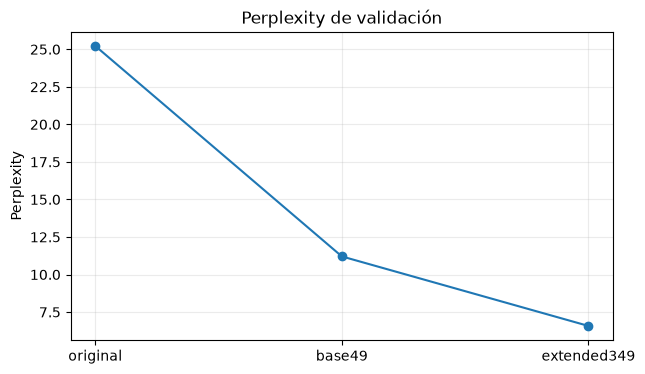

,term,cosine_similarity_base49,cosine_distance_base49,euclidean_distance_base49,cosine_similarity_extended349,cosine_distance_extended349,euclidean_distance_extended349
8,absolución,0.999927,0.000073,0.010564,0.999078,0.000922,0.037396
0,acusado,0.999976,0.000024,0.009526,0.999850,0.000150,0.024077
7,peritaje,0.999960,0.000040,0.007382,0.999873,0.000127,0.012851
4,dictamen,0.999976,0.000024,0.005538,0.999889,0.000111,0.011873
1,testimonio,0.999988,0.000012,0.004183,0.999900,0.000100,0.011843
9,culpabilidad,0.999991,0.000009,0.005331,0.999909,0.000091,0.016755
2,indicio,0.999991,0.000009,0.004419,0.999915,0.000085,0.013941
5,homicidio,0.999992,0.000008,0.004776,0.999919,0.000081,0.015488
3,coautoría,0.999991,0.000009,0.004382,0.999920,0.000080,0.013085
6,sentencia,0.999987,0.000013,0.005174,0.999921,0.000079,0.012686


In [12]:
metrics_df = pd.DataFrame([
    {"stage": "original", "eval_loss": baseline["eval_loss"], "perplexity": baseline["perplexity"]},
    {"stage": "base49", "eval_loss": loss_base, "perplexity": ppl_base},
    {"stage": "extended349", "eval_loss": loss_extended, "perplexity": ppl_extended},
])
display(metrics_df)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(metrics_df["stage"], metrics_df["perplexity"], marker="o")
ax.set_title("Perplexity de validación")
ax.set_ylabel("Perplexity")
ax.grid(alpha=.25)
plt.show()

shift_base = shift_table(emb_original, emb_base, "base49")
shift_extended = shift_table(emb_original, emb_extended, "extended349")
shift_df = shift_base.merge(shift_extended, on="term")
display(shift_df.sort_values("cosine_distance_extended349", ascending=False))

metrics_df.to_csv(DRIVE_ARTIFACTS / "perplexity_metrics.csv", index=False)
shift_df.to_csv(DRIVE_ARTIFACTS / "embedding_shift.csv", index=False)

In [13]:
summary = {
    "model": MODEL_NAME,
    "gpu": GPU_NAME,
    "base_units": 49,
    "added_units": 300,
    "extended_units": 349,
    "validation_units": 44,
    "perplexity_original": baseline["perplexity"],
    "perplexity_base49": ppl_base,
    "perplexity_extended349": ppl_extended,
    "time_base49_seconds": elapsed_base,
    "time_extended349_seconds": elapsed_extended,
    "peak_vram_base49_gb": peak_base,
    "peak_vram_extended349_gb": peak_extended,
}

with (DRIVE_ARTIFACTS / "summary.json").open("w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

summary

{'model': 'distilbert-base-multilingual-cased',
 'gpu': 'Tesla T4',
 'base_units': 49,
 'added_units': 300,
 'extended_units': 349,
 'validation_units': 44,
 'perplexity_original': 25.222326107712917,
 'perplexity_base49': 11.205334305224092,
 'perplexity_extended349': 6.576381836200262,
 'time_base49_seconds': 27.81958136600042,
 'time_extended349_seconds': 87.35255537300054,
 'peak_vram_base49_gb': 5.432877063751221,
 'peak_vram_extended349_gb': 6.448805809020996}

## Interpretación DAPT/TAPT

Esta etapa es **DAPT (Domain-Adaptive Pretraining)**: continuamos el objetivo MLM sobre resoluciones judiciales para mover el modelo hacia el lenguaje del dominio.

No es todavía TAPT en sentido estricto, porque no estamos adaptando el MLM a una tarea supervisada concreta. Las tareas específicas de EvidenceLab —reconstrucción, contradicciones, evaluación de teorías y responsabilidad— se enseñarán después mediante SFT/QLoRA.

Al terminar, documenta:

1. perplexity original;
2. perplexity tras 49 unidades;
3. perplexity tras añadir 300 unidades;
4. al menos dos términos con desplazamiento de embedding;
5. si la adaptación de dominio valió la pena.